Problem Statement: 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Machine_learning_Projects\01_medical_insurance_cost_prediction\medical_insurance.csv")
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [4]:
df.shape

(100000, 54)

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

In [6]:
df.columns

Index(['person_id', 'age', 'sex', 'region', 'urban_rural', 'income',
       'education', 'marital_status', 'employment_status', 'household_size',
       'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
       'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
       'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
       'annual_medical_cost', 'annual_premium', 'monthly_premium',
       'claims_count', 'avg_claim_amount', 'total_claims_paid',
       'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd',
       'cardiovascular_disease', 'cancer_history', 'kidney_disease',
       'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count',
       'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count', 'is_high_risk', 'had_major_procedure'],
      

In [7]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

In [9]:
df["alcohol_freq"].isnull().mean() * 100

np.float64(30.083)

The alcohol freq col have approximately 30 percent null values so we will be handling that data like this :

In [10]:
df["alcohol_freq"] = df["alcohol_freq"].fillna("Unknown")

In [11]:
df.isnull().sum()

person_id                      0
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_med

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

In [13]:
df = df.drop(columns=['person_id'])#dropped the column id

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   sex                          100000 non-null  str    
 2   region                       100000 non-null  str    
 3   urban_rural                  100000 non-null  str    
 4   income                       100000 non-null  float64
 5   education                    100000 non-null  str    
 6   marital_status               100000 non-null  str    
 7   employment_status            100000 non-null  str    
 8   household_size               100000 non-null  int64  
 9   dependents                   100000 non-null  int64  
 10  bmi                          100000 non-null  float64
 11  smoker                       100000 non-null  str    
 12  alcohol_freq                 100000 non-null  str    
 13  visits_last

Now lets encode and map our data

In [15]:
df['sex'].value_counts()

sex
Female    49193
Male      48794
Other      2013
Name: count, dtype: int64

In [16]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True)

In [17]:
df.head()

,age,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,...,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,sex_Male,sex_Other
0,52,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,...,0,1,0,2,0,1,0,0,False,False
1,79,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,...,1,0,0,1,0,1,1,0,False,False
2,68,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,...,1,1,0,2,1,0,1,0,True,False
3,15,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,...,0,1,0,0,1,0,0,0,True,False
4,53,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,...,0,2,0,1,1,0,1,0,True,False


In [18]:
df['region'].value_counts()

region
South      28029
North      22027
East       19984
West       17879
Central    12081
Name: count, dtype: int64

In [19]:
df = pd.get_dummies(df, columns=['region'],drop_first='True')

In [20]:
df.head()

,age,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,...,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,sex_Male,sex_Other,region_East,region_North,region_South,region_West
0,52,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,...,0,1,0,0,False,False,False,True,False,False
1,79,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,...,0,1,1,0,False,False,False,True,False,False
2,68,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,...,1,0,1,0,True,False,False,True,False,False
3,15,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,...,1,0,0,0,True,False,False,True,False,False
4,53,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,...,1,0,1,0,True,False,False,False,False,False


In [21]:
df['urban_rural'].value_counts()

urban_rural
Urban       60019
Suburban    25021
Rural       14960
Name: count, dtype: int64

In [22]:
df = pd.get_dummies(df,columns = ['urban_rural'],drop_first = 'True')

In [23]:
df.head()

,age,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,...,is_high_risk,had_major_procedure,sex_Male,sex_Other,region_East,region_North,region_South,region_West,urban_rural_Suburban,urban_rural_Urban
0,52,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,Unknown,...,0,0,False,False,False,True,False,False,True,False
1,79,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,...,1,0,False,False,False,True,False,False,False,True
2,68,40700.0,HS,Married,Retired,5,3,31.5,Never,Unknown,...,1,0,True,False,False,True,False,False,False,False
3,15,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,Unknown,...,0,0,True,False,False,True,False,False,True,False
4,53,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,...,1,0,True,False,False,False,False,False,True,False


In [24]:
df['education'].value_counts()

education
Bachelors       27996
Some College    25112
HS              24827
Masters         13987
No HS            5120
Doctorate        2958
Name: count, dtype: int64

In [25]:
df = pd.get_dummies(df,columns=['education'],drop_first="True")

In [26]:
df.head()

,age,income,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,...,region_North,region_South,region_West,urban_rural_Suburban,urban_rural_Urban,education_Doctorate,education_HS,education_Masters,education_No HS,education_Some College
0,52,22700.0,Married,Retired,3,1,27.4,Never,Unknown,2,...,True,False,False,True,False,True,False,False,False,False
1,79,12800.0,Married,Employed,3,1,26.6,Never,Weekly,2,...,True,False,False,False,True,False,False,False,True,False
2,68,40700.0,Married,Retired,5,3,31.5,Never,Unknown,1,...,True,False,False,False,False,False,True,False,False,False
3,15,15600.0,Married,Self-employed,5,3,31.6,Never,Unknown,0,...,True,False,False,True,False,False,False,False,False,True
4,53,89600.0,Married,Self-employed,2,0,30.5,Never,Daily,3,...,False,False,False,True,False,True,False,False,False,False


In [27]:
df['marital_status'].value_counts()

marital_status
Married     53252
Single      35715
Divorced     6984
Widowed      4049
Name: count, dtype: int64

In [28]:
df = pd.get_dummies(df,columns=['marital_status'],drop_first="True")

In [29]:
df.head()

,age,income,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,...,urban_rural_Suburban,urban_rural_Urban,education_Doctorate,education_HS,education_Masters,education_No HS,education_Some College,marital_status_Married,marital_status_Single,marital_status_Widowed
0,52,22700.0,Retired,3,1,27.4,Never,Unknown,2,0,...,True,False,True,False,False,False,False,True,False,False
1,79,12800.0,Employed,3,1,26.6,Never,Weekly,2,0,...,False,True,False,False,False,True,False,True,False,False
2,68,40700.0,Retired,5,3,31.5,Never,Unknown,1,0,...,False,False,False,True,False,False,False,True,False,False
3,15,15600.0,Self-employed,5,3,31.6,Never,Unknown,0,0,...,True,False,False,False,False,False,True,True,False,False
4,53,89600.0,Self-employed,2,0,30.5,Never,Daily,3,0,...,True,False,True,False,False,False,False,True,False,False


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 64 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   income                       100000 non-null  float64
 2   employment_status            100000 non-null  str    
 3   household_size               100000 non-null  int64  
 4   dependents                   100000 non-null  int64  
 5   bmi                          100000 non-null  float64
 6   smoker                       100000 non-null  str    
 7   alcohol_freq                 100000 non-null  str    
 8   visits_last_year             100000 non-null  int64  
 9   hospitalizations_last_3yrs   100000 non-null  int64  
 10  days_hospitalized_last_3yrs  100000 non-null  int64  
 11  medication_count             100000 non-null  int64  
 12  systolic_bp                  100000 non-null  float64
 13  diastolic_b

In [31]:
df['employment_status'].value_counts()

employment_status
Employed         55269
Retired          19864
Unemployed       12939
Self-employed    11928
Name: count, dtype: int64

In [32]:
df = pd.get_dummies(df,columns=['employment_status'],drop_first="True")

In [33]:
df.head()

,age,income,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,...,education_HS,education_Masters,education_No HS,education_Some College,marital_status_Married,marital_status_Single,marital_status_Widowed,employment_status_Retired,employment_status_Self-employed,employment_status_Unemployed
0,52,22700.0,3,1,27.4,Never,Unknown,2,0,0,...,False,False,False,False,True,False,False,True,False,False
1,79,12800.0,3,1,26.6,Never,Weekly,2,0,0,...,False,False,True,False,True,False,False,False,False,False
2,68,40700.0,5,3,31.5,Never,Unknown,1,0,0,...,True,False,False,False,True,False,False,True,False,False
3,15,15600.0,5,3,31.6,Never,Unknown,0,0,0,...,False,False,False,True,True,False,False,False,True,False
4,53,89600.0,2,0,30.5,Never,Daily,3,0,0,...,False,False,False,False,True,False,False,False,True,False


In [34]:
df['smoker'].value_counts()

smoker
Never      69709
Former     18163
Current    12128
Name: count, dtype: int64

In [35]:
df["smoker"] = df["smoker"].map({'Never':0,'Former':1,'Current':2})

In [36]:
df.head()

,age,income,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,...,education_HS,education_Masters,education_No HS,education_Some College,marital_status_Married,marital_status_Single,marital_status_Widowed,employment_status_Retired,employment_status_Self-employed,employment_status_Unemployed
0,52,22700.0,3,1,27.4,0,Unknown,2,0,0,...,False,False,False,False,True,False,False,True,False,False
1,79,12800.0,3,1,26.6,0,Weekly,2,0,0,...,False,False,True,False,True,False,False,False,False,False
2,68,40700.0,5,3,31.5,0,Unknown,1,0,0,...,True,False,False,False,True,False,False,True,False,False
3,15,15600.0,5,3,31.6,0,Unknown,0,0,0,...,False,False,False,True,True,False,False,False,True,False
4,53,89600.0,2,0,30.5,0,Daily,3,0,0,...,False,False,False,False,True,False,False,False,True,False


In [37]:
df['alcohol_freq'].value_counts()

alcohol_freq
Occasional    45078
Unknown       30083
Weekly        19833
Daily          5006
Name: count, dtype: int64

In [38]:
df = pd.get_dummies(df, columns=['alcohol_freq'], drop_first=True)

In [39]:
df.head()

,age,income,household_size,dependents,bmi,smoker,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,education_Some College,marital_status_Married,marital_status_Single,marital_status_Widowed,employment_status_Retired,employment_status_Self-employed,employment_status_Unemployed,alcohol_freq_Occasional,alcohol_freq_Unknown,alcohol_freq_Weekly
0,52,22700.0,3,1,27.4,0,2,0,0,4,...,False,True,False,False,True,False,False,False,True,False
1,79,12800.0,3,1,26.6,0,2,0,0,3,...,False,True,False,False,False,False,False,False,False,True
2,68,40700.0,5,3,31.5,0,1,0,0,4,...,False,True,False,False,True,False,False,False,True,False
3,15,15600.0,5,3,31.6,0,0,0,0,1,...,True,True,False,False,False,True,False,False,True,False
4,53,89600.0,2,0,30.5,0,3,0,0,2,...,False,True,False,False,False,True,False,False,False,False


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 68 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              100000 non-null  int64  
 1   income                           100000 non-null  float64
 2   household_size                   100000 non-null  int64  
 3   dependents                       100000 non-null  int64  
 4   bmi                              100000 non-null  float64
 5   smoker                           100000 non-null  int64  
 6   visits_last_year                 100000 non-null  int64  
 7   hospitalizations_last_3yrs       100000 non-null  int64  
 8   days_hospitalized_last_3yrs      100000 non-null  int64  
 9   medication_count                 100000 non-null  int64  
 10  systolic_bp                      100000 non-null  float64
 11  diastolic_bp                     100000 non-null  float64
 12  ldl           

In [41]:
df['plan_type'].value_counts()

plan_type
PPO    35167
HMO    34723
EPO    15121
POS    14989
Name: count, dtype: int64

In [42]:
df = pd.get_dummies(df,columns=['plan_type'],drop_first="True")

In [43]:
df.head()

,age,income,household_size,dependents,bmi,smoker,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,marital_status_Widowed,employment_status_Retired,employment_status_Self-employed,employment_status_Unemployed,alcohol_freq_Occasional,alcohol_freq_Unknown,alcohol_freq_Weekly,plan_type_HMO,plan_type_POS,plan_type_PPO
0,52,22700.0,3,1,27.4,0,2,0,0,4,...,False,True,False,False,False,True,False,False,False,True
1,79,12800.0,3,1,26.6,0,2,0,0,3,...,False,False,False,False,False,False,True,False,True,False
2,68,40700.0,5,3,31.5,0,1,0,0,4,...,False,True,False,False,False,True,False,True,False,False
3,15,15600.0,5,3,31.6,0,0,0,0,1,...,False,False,True,False,False,True,False,True,False,False
4,53,89600.0,2,0,30.5,0,3,0,0,2,...,False,False,True,False,False,False,False,False,True,False


In [44]:
df['network_tier'].value_counts()

network_tier
Silver      40177
Bronze      29932
Gold        19882
Platinum    10009
Name: count, dtype: int64

In [45]:
df["network_tier"] = df["network_tier"].map({"Bronze": 0,"Silver": 1,"Gold": 2,"Platinum": 3})

In [46]:
df['network_tier'].value_counts()

network_tier
1    40177
0    29932
2    19882
3    10009
Name: count, dtype: int64

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              100000 non-null  int64  
 1   income                           100000 non-null  float64
 2   household_size                   100000 non-null  int64  
 3   dependents                       100000 non-null  int64  
 4   bmi                              100000 non-null  float64
 5   smoker                           100000 non-null  int64  
 6   visits_last_year                 100000 non-null  int64  
 7   hospitalizations_last_3yrs       100000 non-null  int64  
 8   days_hospitalized_last_3yrs      100000 non-null  int64  
 9   medication_count                 100000 non-null  int64  
 10  systolic_bp                      100000 non-null  float64
 11  diastolic_bp                     100000 non-null  float64
 12  ldl           

In [48]:
df.duplicated().sum()#No duplicate values

np.int64(0)

Now lets start Visualization

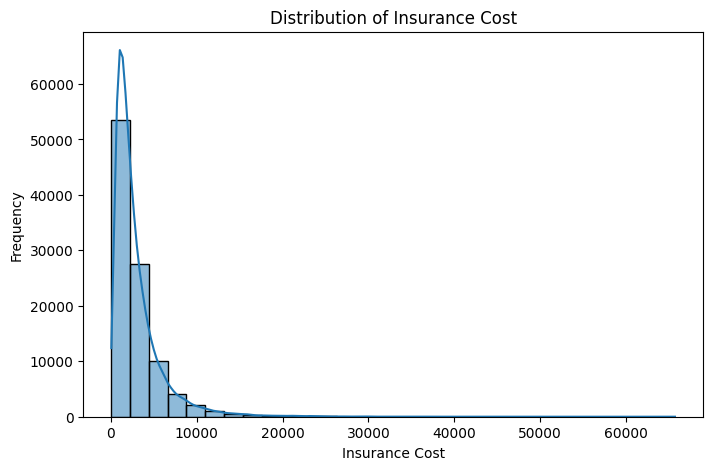

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(df["annual_medical_cost"], bins=30, kde=True)
plt.title("Distribution of Insurance Cost")
plt.xlabel("Insurance Cost")
plt.ylabel("Frequency")
plt.show()

The target variable (insurance_cost) is positively (right) skewed. Most policyholders have relatively low insurance costs, while a small number have significantly higher costs, resulting in a long right tail. The distribution is not normal, indicating the presence of high-cost cases that may influence the regression model.

In [50]:
df.columns

Index(['age', 'income', 'household_size', 'dependents', 'bmi', 'smoker',
       'visits_last_year', 'hospitalizations_last_3yrs',
       'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
       'diastolic_bp', 'ldl', 'hba1c', 'network_tier', 'deductible', 'copay',
       'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality',
       'risk_score', 'annual_medical_cost', 'annual_premium',
       'monthly_premium', 'claims_count', 'avg_claim_amount',
       'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes',
       'asthma', 'copd', 'cardiovascular_disease', 'cancer_history',
       'kidney_disease', 'liver_disease', 'arthritis', 'mental_health',
       'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
       'proc_consult_count', 'proc_lab_count', 'is_high_risk',
       'had_major_procedure', 'sex_Male', 'sex_Other', 'region_East',
       'region_North', 'region_South', 'region_West', 'urban_rural_Suburban',
       'urban_rural_Ur

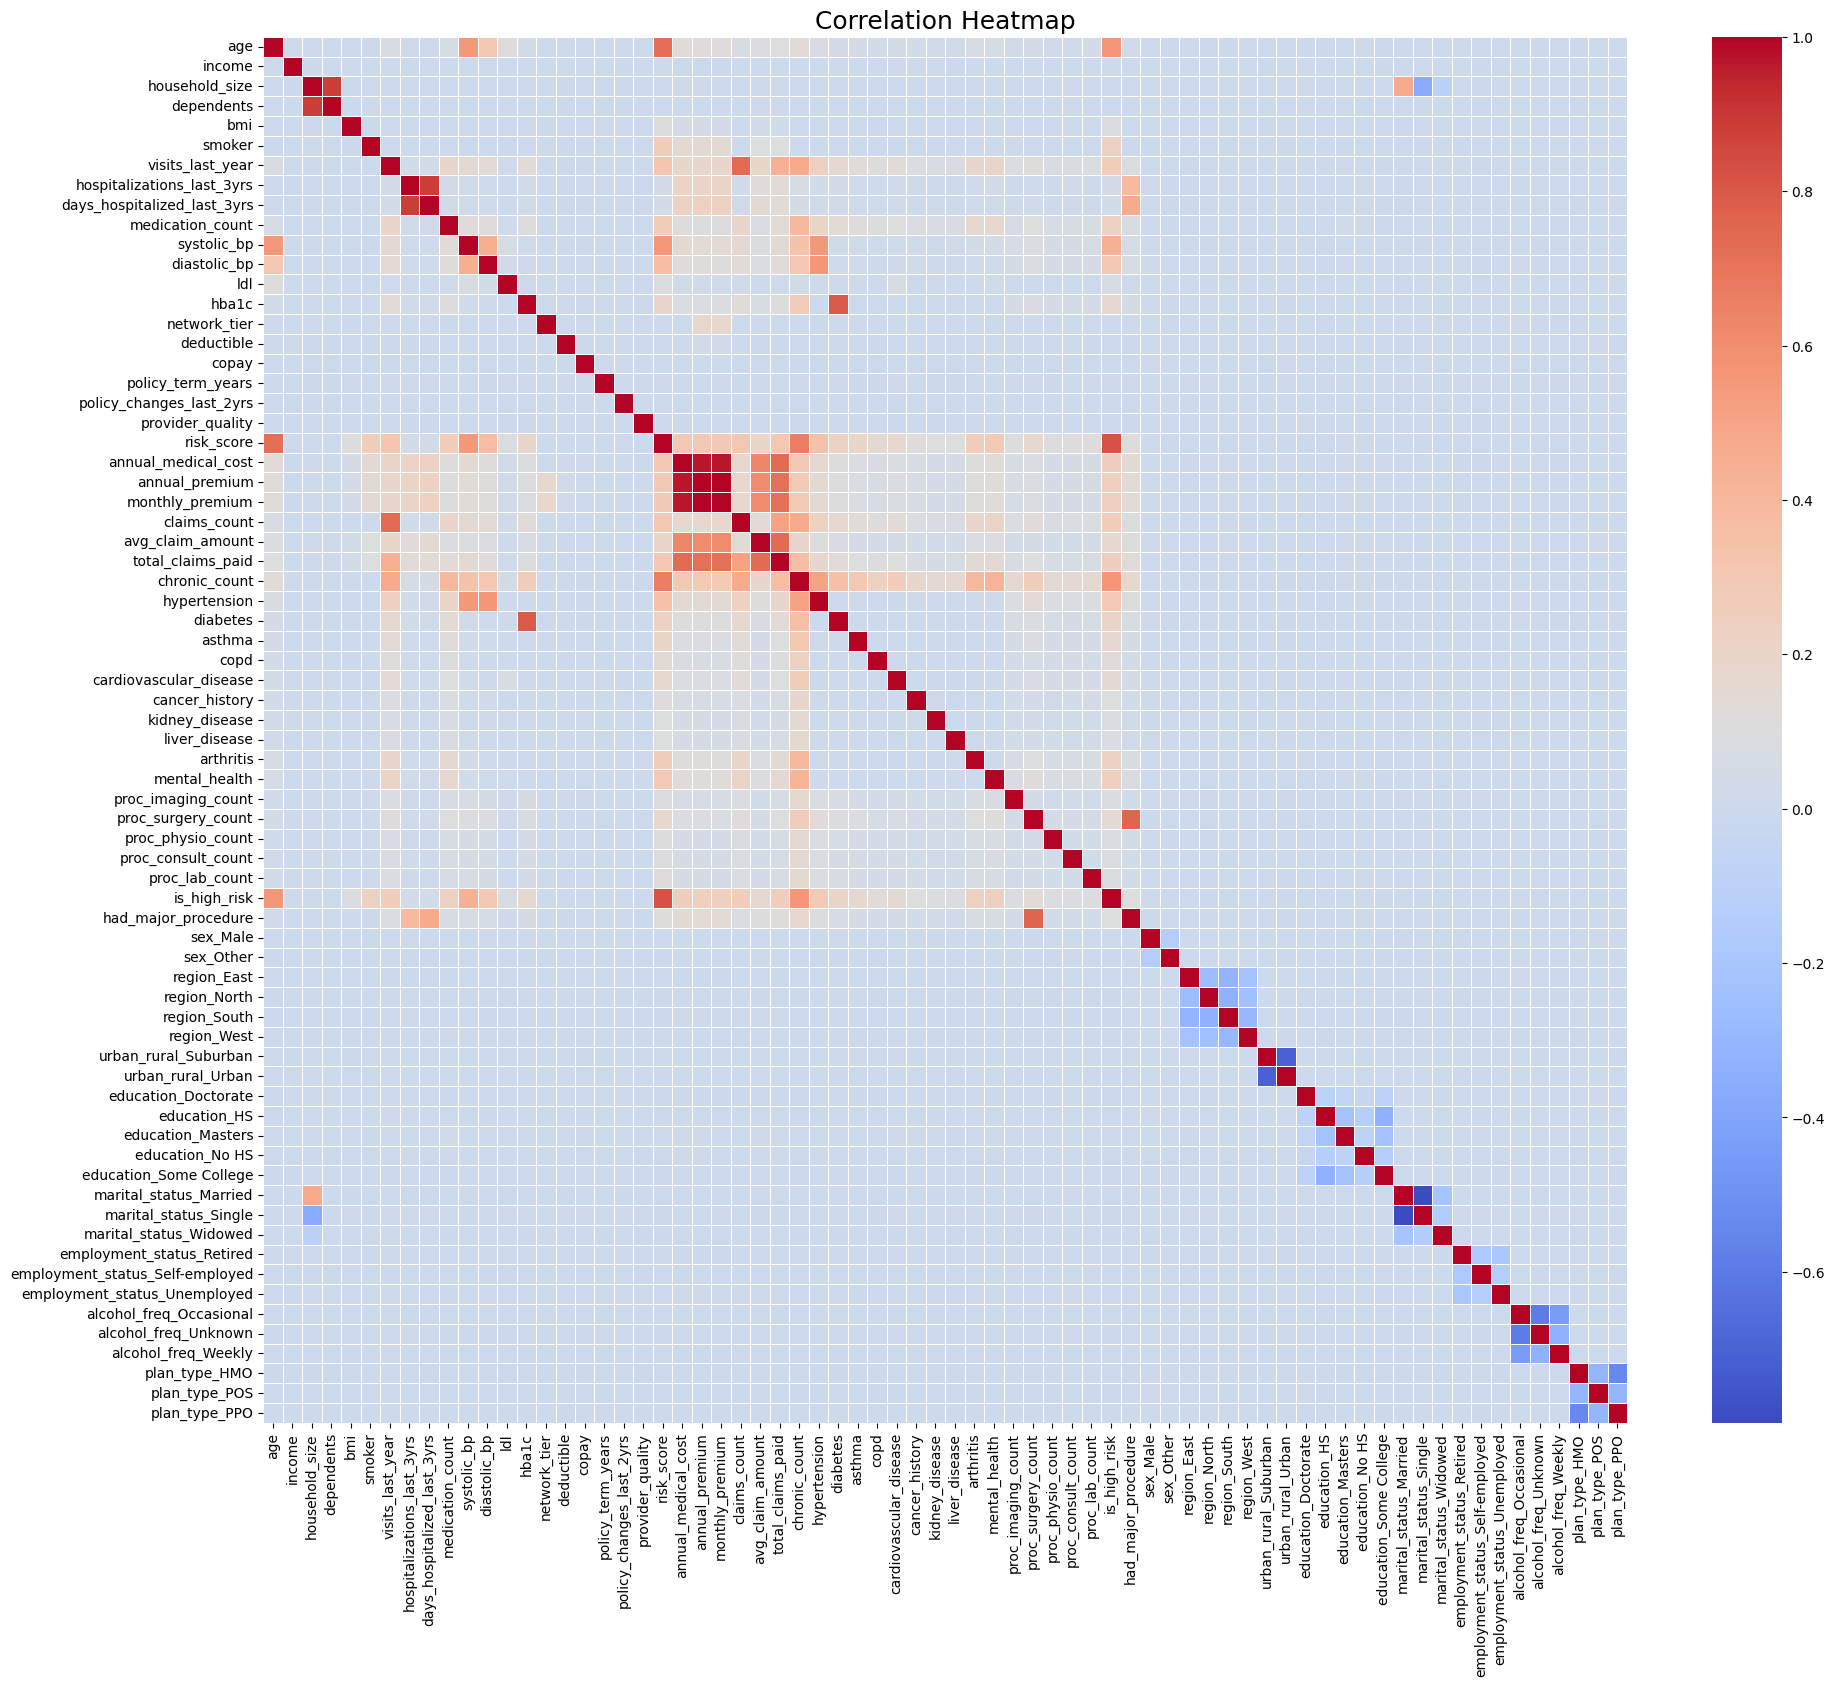

In [51]:

plt.figure(figsize=(22, 18))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

In [52]:
corr = df.corr(numeric_only=True)

corr["annual_medical_cost"].sort_values(ascending=False)

annual_medical_cost          1.000000
monthly_premium              0.965416
annual_premium               0.965415
total_claims_paid            0.739402
avg_claim_amount             0.632996
                               ...   
provider_quality            -0.003214
employment_status_Retired   -0.003341
region_East                 -0.004393
education_Doctorate         -0.005363
income                      -0.005974
Name: annual_medical_cost, Length: 70, dtype: float64

In [53]:
cols_to_drop = [
    "annual_premium",
    "monthly_premium",
    "total_claims_paid",
    "avg_claim_amount"
]

df.drop(columns=cols_to_drop, inplace=True)

In [54]:
corr = df.corr(numeric_only=True)

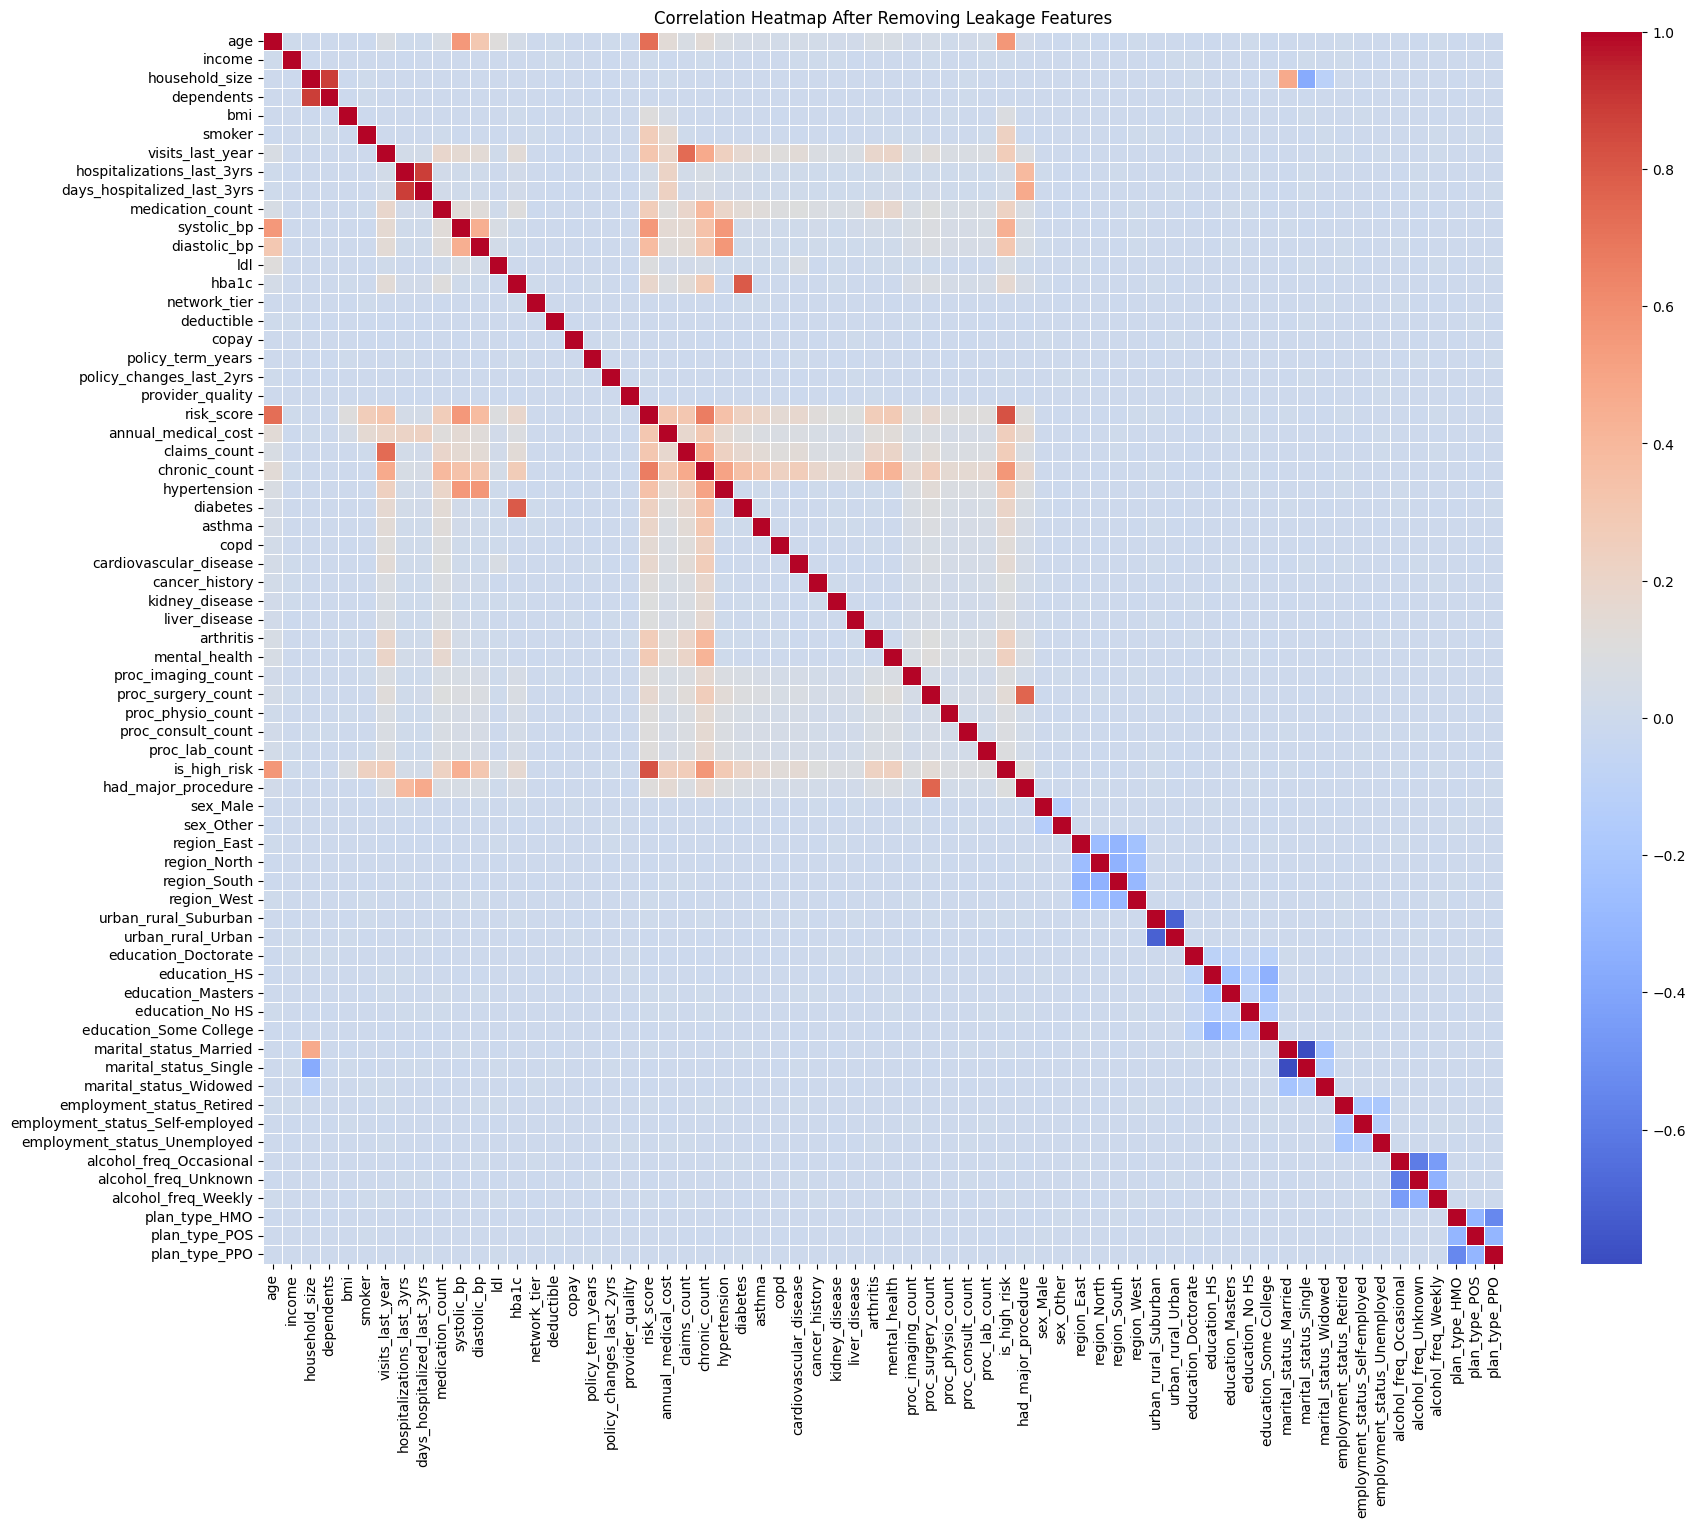

In [55]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap After Removing Leakage Features")
plt.show()

In [56]:
corr["annual_medical_cost"].sort_values(ascending=False).head(15)

annual_medical_cost            1.000000
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
claims_count                   0.179082
smoker                         0.155642
hypertension                   0.154309
had_major_procedure            0.148292
systolic_bp                    0.145070
age                            0.131166
mental_health                  0.126232
diastolic_bp                   0.117647
Name: annual_medical_cost, dtype: float64

Visualisations

Numerical Columns histogram

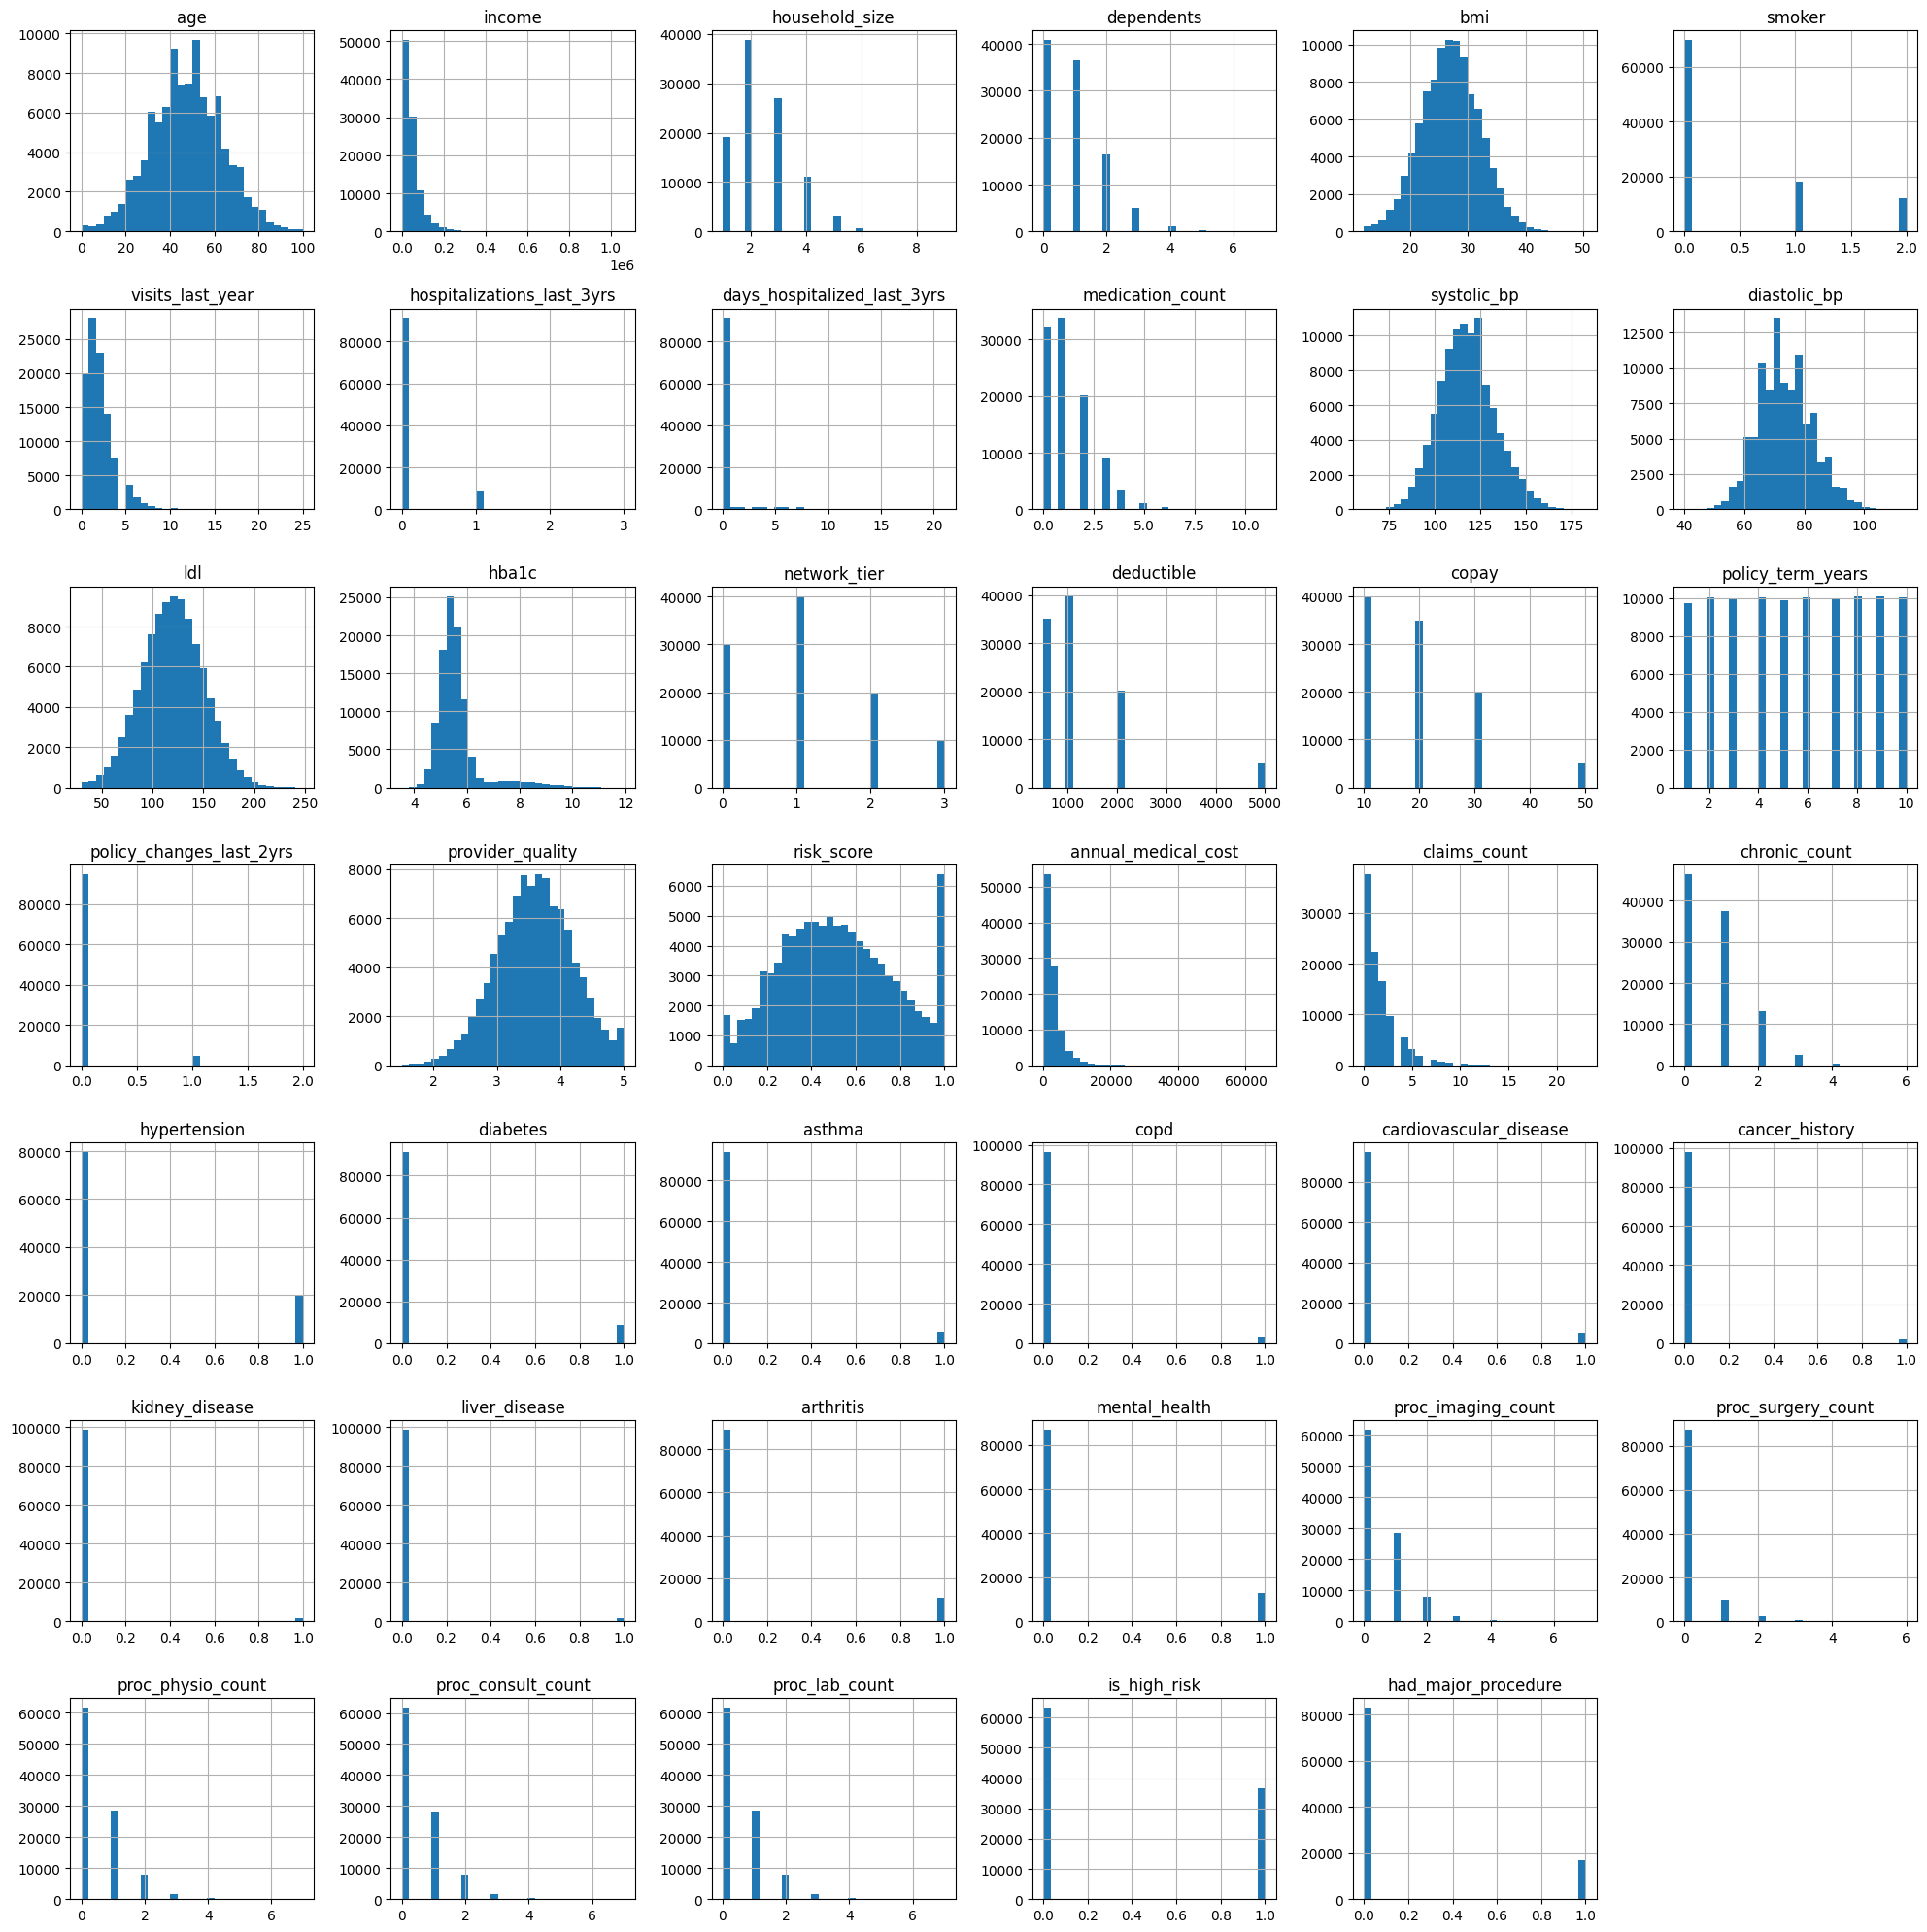

In [57]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols].hist(figsize=(20,20), bins=30)
plt.tight_layout()
plt.show()

Observation:
1.Most numerical features exhibit either an approximately normal distribution or a positively skewed distribution.
2.Healthcare utilization variables such as annual medical cost, claims count, hospital visits, and procedure counts are positively skewed, indicating that most individuals incur relatively low utilization while a small proportion account for much higher values.
3.Demographic and physiological variables such as age, BMI, systolic blood pressure, diastolic blood pressure, LDL cholesterol, and provider quality are approximately normally distributed.
4.Several features are discrete or binary in nature (e.g., chronic diseases, smoking status, network tier, deductible, copay), resulting in non-continuous distributions, which is expected.
5.The target variable, annual_medical_cost, is highly right-skewed, suggesting that while most individuals have relatively low medical expenses, a small number incur substantially higher healthcare costs.
6.No obvious data quality issues or unrealistic distributions were observed from the feature histograms. Some variables exhibit long right tails, which are expected in real-world healthcare and insurance datasets and will be further examined using boxplots for potential outliers.

In [67]:
boxplot_cols = [
    "age",
    "income",
    "household_size",
    "dependents",
    "bmi",
    "visits_last_year",
    "hospitalizations_last_3yrs",
    "days_hospitalized_last_3yrs",
    "medication_count",
    "systolic_bp",
    "diastolic_bp",
    "ldl",
    "hba1c",
    "network_tier",
    "deductible",
    "copay",
    "policy_term_years",
    "policy_changes_last_2yrs",
    "provider_quality",
    "risk_score",
    "annual_medical_cost",
    "claims_count",
    "chronic_count",
    "proc_imaging_count",
    "proc_surgery_count",
    "proc_physio_count",
    "proc_consult_count",
    "proc_lab_count"
]

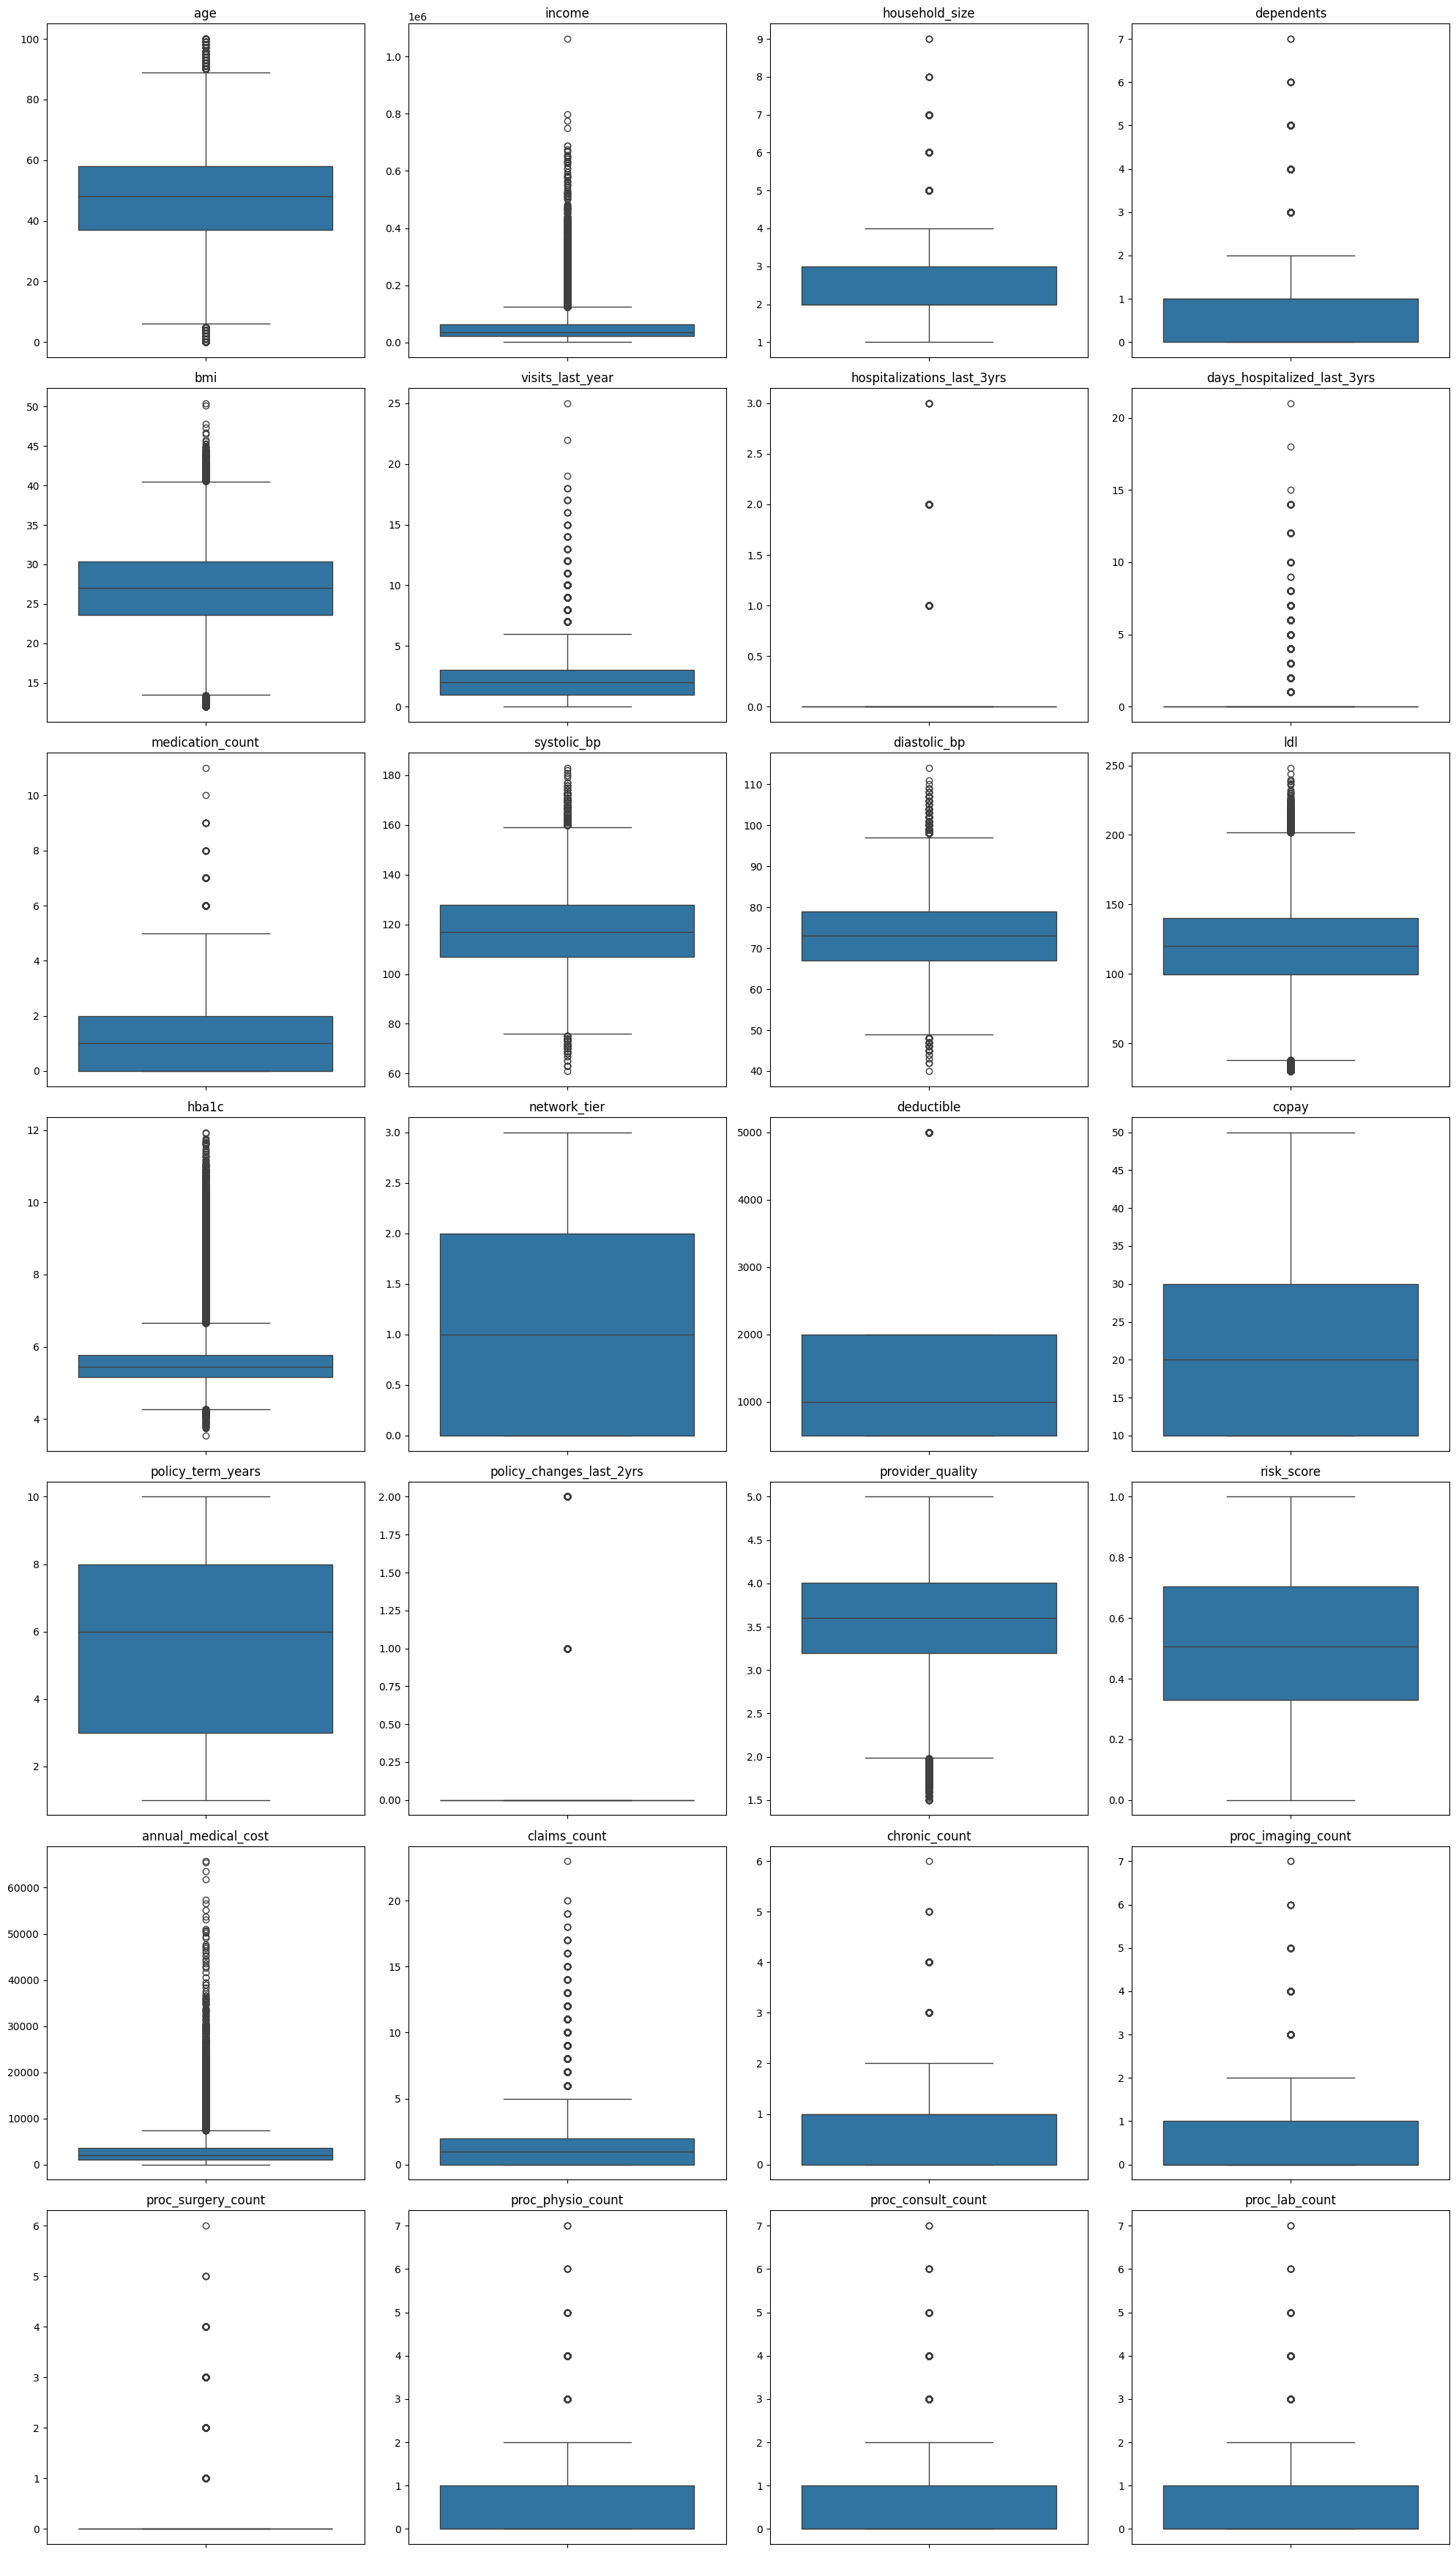

In [68]:
import math
n_cols = 4
n_rows = math.ceil(len(boxplot_cols) / n_cols)
plt.figure(figsize=(20, n_rows * 5))
for i, col in enumerate(boxplot_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

Observation: Several numerical features exhibit statistical outliers, particularly healthcare utilization and cost-related variables. However, these values appear consistent with real-world medical and insurance data rather than data entry errors. Therefore, no outliers were removed during preprocessing, allowing the model to learn from the complete range of valid observations.

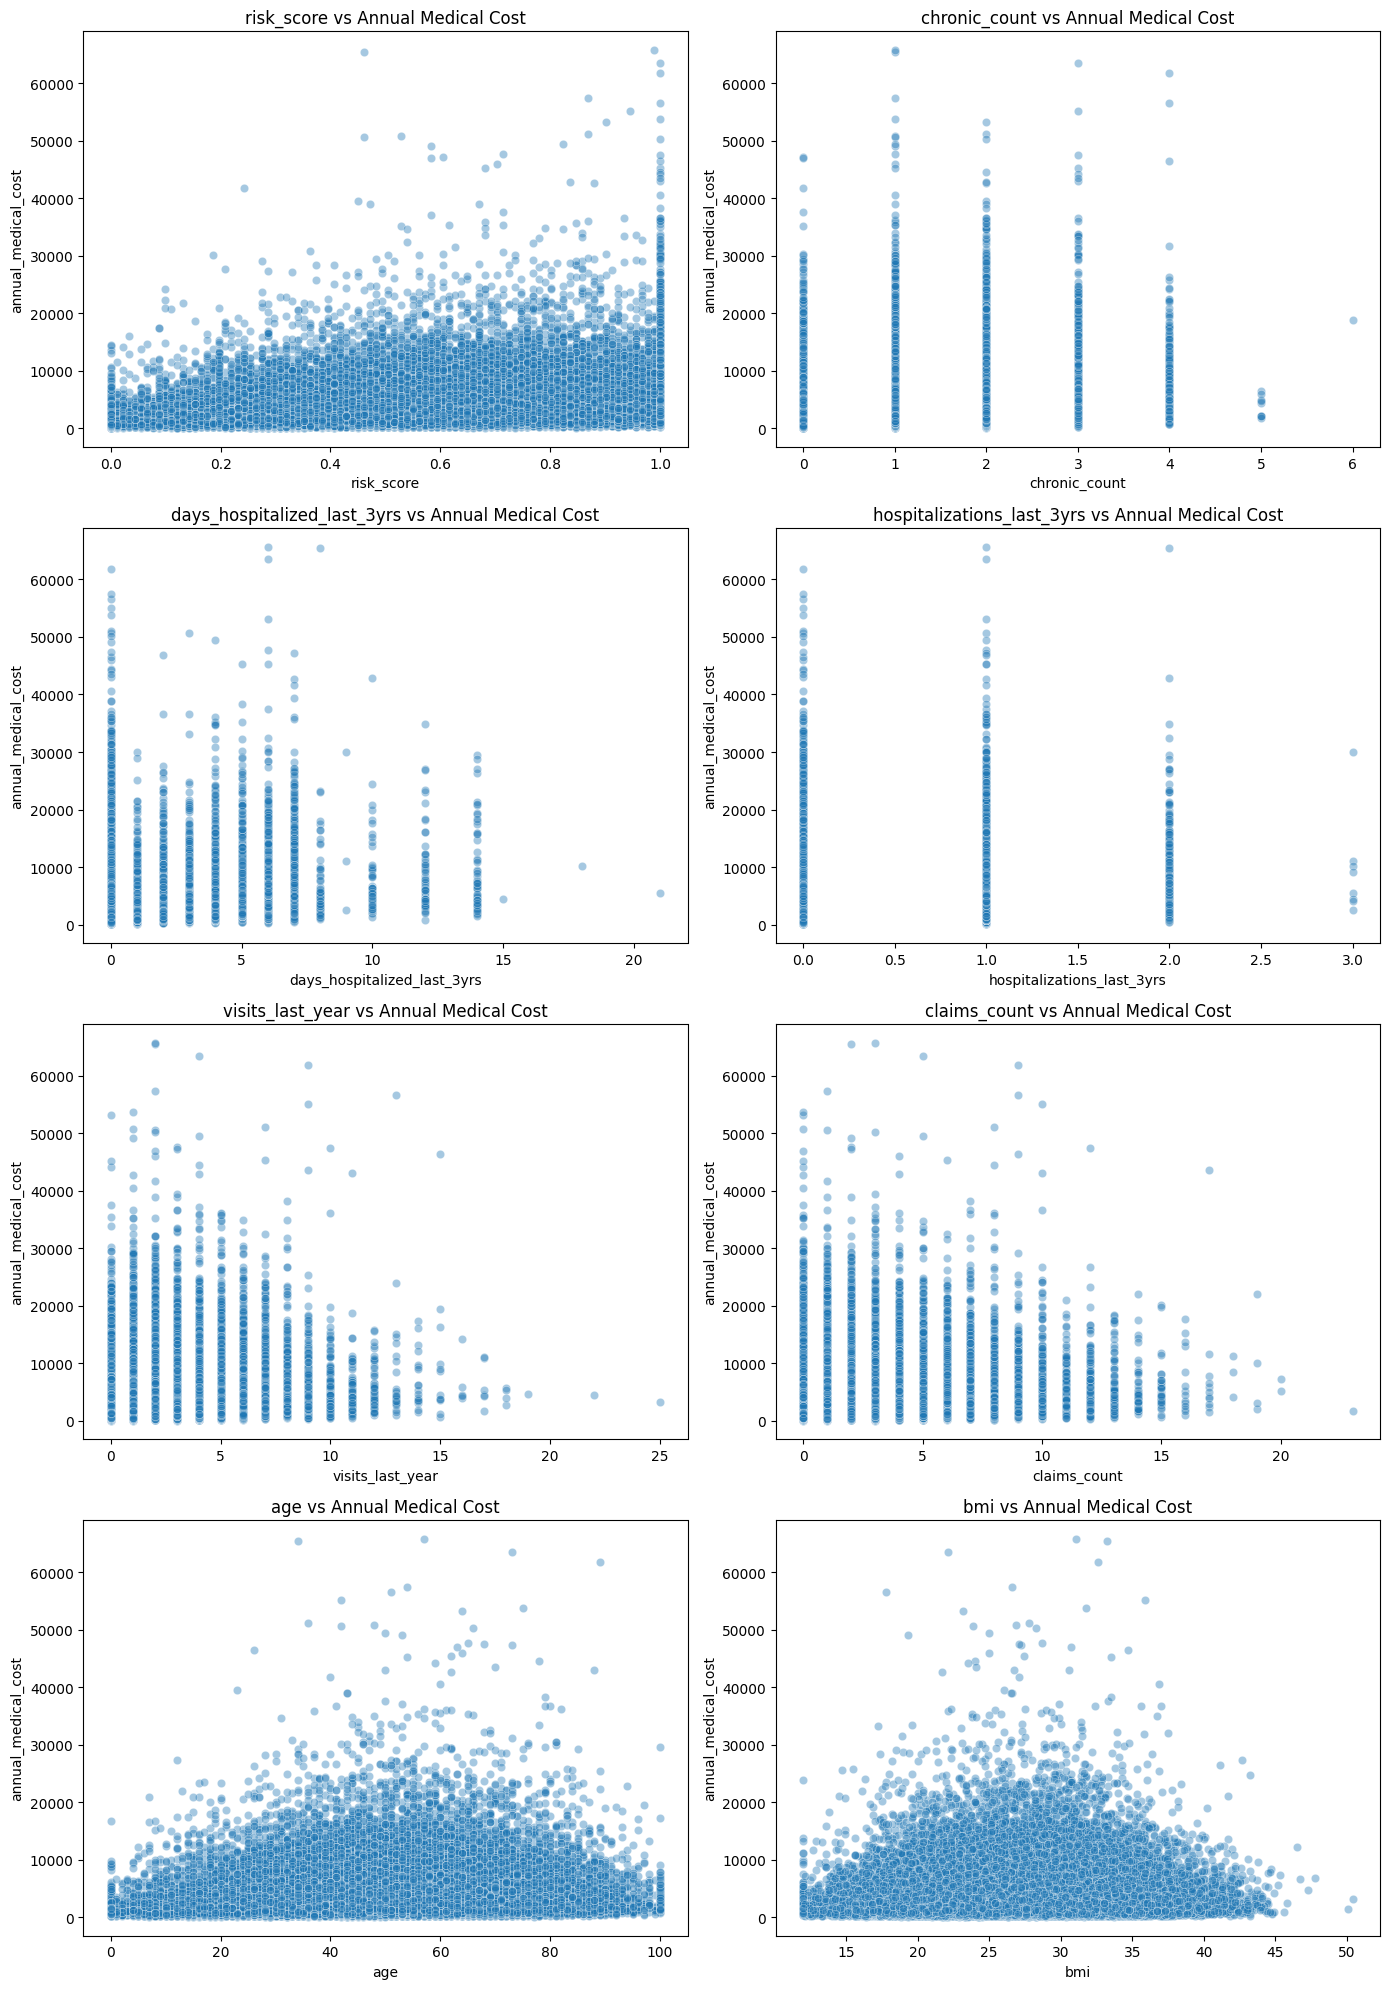

In [70]:
scatter_cols = [# Sorted the columns from heatmap according to their corelation with output
    "risk_score",
    "chronic_count",
    "days_hospitalized_last_3yrs",
    "hospitalizations_last_3yrs",
    "visits_last_year",
    "claims_count",
    "age",
    "bmi"
]
n_cols = 2
n_rows = math.ceil(len(scatter_cols) / n_cols)
plt.figure(figsize=(14, n_rows * 5))
for i, col in enumerate(scatter_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(
        x=df[col],
        y=df["annual_medical_cost"],
        alpha=0.4
    )
    plt.title(f"{col} vs Annual Medical Cost")
plt.tight_layout()
plt.show()

Observation: Scatter plots were used to examine the relationship between important predictor variables and the target variable (annual_medical_cost). Features such as risk_score, chronic_count, and days_hospitalized_last_3yrs exhibit a moderate positive relationship with medical cost, while variables such as age and BMI show weaker, non-linear patterns. Most healthcare utilization features display considerable variability, indicating that annual medical cost is influenced by multiple interacting factors rather than a single predictor.